# MLOps Assignment 4 — English→Hindi Transformer with Ray Tune + Optuna

**Fix applied:** Proper 80/20 train/val split so that baseline and tuned model are both evaluated on held-out data. Ray Tune now optimizes validation BLEU instead of training loss.

In [1]:
# ============================================================
# CELL 1: HuggingFace Login
# ============================================================
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login, whoami

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_APi_KEY")

login(token=secret_value_0)

try:
    user_info = whoami()
    print(f"\n✅ Successfully logged in as: {user_info['name']}")
except Exception as e:
    print("\n❌ Login failed. Please check your API key and internet connection.")


✅ Successfully logged in as: DuckyDuck123


Device : cuda
GPU    : Tesla T4
VRAM   : 15.64 GB
Total pairs (full dataset): 13186
Using 40% subset → 5274 pairs
                               en                                       hi
0   I owe what I am to my friend.  मैं जो भी हूँ मेरे दोस्त की वजह से हूँ।
1  They must have made a mistake.                   उनसे ग़लती हो गई होगी।
2             They can't see Tom.                 वे टॉम को नहीं देख सकते।
EN vocab: 2111  |  HI vocab: 2143
Train split: 4219 pairs  |  Val split: 1055 pairs


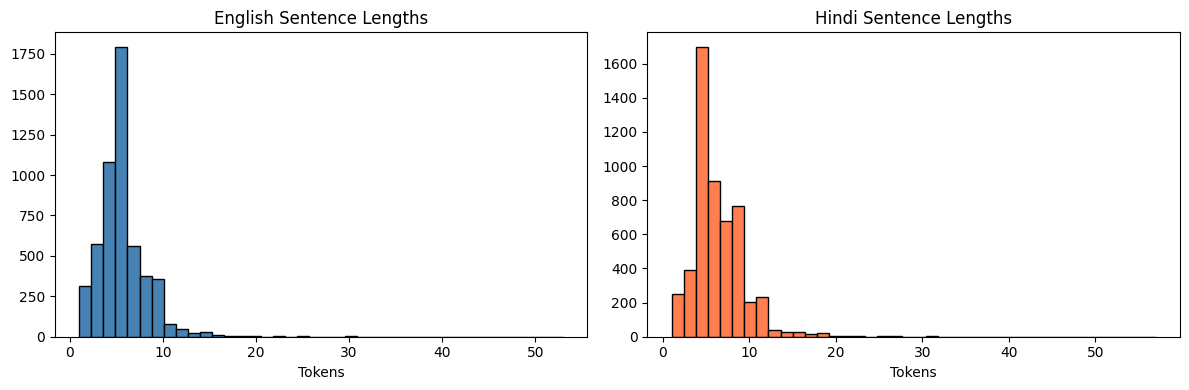

✅ Data, Vocabulary & Train/Val Split ready


In [2]:
# ============================================================
# CELL 2: Imports, Data, Vocabulary, Dataset, EDA
# FIX: Added 80/20 train/val split — evaluation is now on
#      held-out validation data, not the training set.
# ============================================================
import os, gc, math, time, warnings, json, pickle
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

import nltk
nltk.download("punkt", quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {round(torch.cuda.get_device_properties(0).total_memory/1e9,2)} GB")

# ── Load dataset ──────────────────────────────────────────────
file_id = "1kluZCW1QqMFZgH89wUfy5FixC9zvsowj"
url     = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url, sep="\t", header=None, names=["id1","en","id2","hi"])
df = df[["en","hi"]].dropna().reset_index(drop=True)
print(f"Total pairs (full dataset): {len(df)}")

# ── Use 40% subset of original dataset ───────────────────────
DATASET_FRACTION = 0.40
df = df.sample(frac=DATASET_FRACTION, random_state=42).reset_index(drop=True)
print(f"Using {int(DATASET_FRACTION*100)}% subset → {len(df)} pairs")
print(df.head(3))

# ── Vocabulary ────────────────────────────────────────────────
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.itos = {0:"<pad>", 1:"<sos>", 2:"<eos>", 3:"<unk>"}
        self.stoi = {v:k for k,v in self.itos.items()}
        self.freq_threshold = freq_threshold
        self.idx = 4

    def build_vocab(self, sentences):
        freq = Counter()
        for s in sentences:
            freq.update(s.lower().strip().split())
        for w, f in freq.items():
            if f >= self.freq_threshold:
                self.stoi[w] = self.idx
                self.itos[self.idx] = w
                self.idx += 1

    def encode(self, sentence, maxlen=MAX_LEN):
        toks = sentence.lower().strip().split()[:maxlen-2]
        ids  = [SOS_IDX] + [self.stoi.get(t, UNK_IDX) for t in toks] + [EOS_IDX]
        ids += [PAD_IDX] * (maxlen - len(ids))
        return ids[:maxlen]

    def decode(self, ids):
        out = []
        for i in ids:
            if i == EOS_IDX: break
            if i not in (PAD_IDX, SOS_IDX):
                out.append(self.itos.get(i, "<unk>"))
        return " ".join(out)

    def __len__(self): return self.idx

en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)
en_vocab.build_vocab(df["en"].tolist())
hi_vocab.build_vocab(df["hi"].tolist())
SRC_VOCAB = len(en_vocab)
TGT_VOCAB = len(hi_vocab)
print(f"EN vocab: {SRC_VOCAB}  |  HI vocab: {TGT_VOCAB}")

# ── Dataset ───────────────────────────────────────────────────
class TranslationDataset(Dataset):
    def __init__(self, df, ev, hv):
        self.src = [ev.encode(s) for s in df["en"]]
        self.tgt = [hv.encode(s) for s in df["hi"]]

    def __len__(self): return len(self.src)

    def __getitem__(self, idx):
        s = torch.tensor(self.src[idx], dtype=torch.long)
        t = torch.tensor(self.tgt[idx], dtype=torch.long)
        return s, t[:-1], t[1:]

full_ds = TranslationDataset(df, en_vocab, hi_vocab)

# ── FIX: 80/20 train/val split ────────────────────────────────
# Previously there was NO split — both models were scored on
# training data, so the 100-epoch baseline inflated its BLEU
# by memorisation, making the tuned model look worse.
train_size = int(0.8 * len(full_ds))
val_size   = len(full_ds) - train_size
train_ds, val_ds = random_split(
    full_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
print(f"Train split: {len(train_ds)} pairs  |  Val split: {len(val_ds)} pairs")

def make_loader(batch_size, split="train", shuffle=True):
    ds = train_ds if split == "train" else val_ds
    return DataLoader(ds, batch_size=batch_size,
                      shuffle=shuffle, num_workers=0, drop_last=False)

# ── EDA plots ─────────────────────────────────────────────────
df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["hi_len"] = df["hi"].apply(lambda x: len(x.split()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["en_len"], bins=40, color="steelblue", edgecolor="black")
axes[0].set_title("English Sentence Lengths"); axes[0].set_xlabel("Tokens")
axes[1].hist(df["hi_len"], bins=40, color="coral", edgecolor="black")
axes[1].set_title("Hindi Sentence Lengths");   axes[1].set_xlabel("Tokens")
plt.tight_layout(); plt.savefig("eda_lengths.png", dpi=120); plt.show()
print("✅ Data, Vocabulary & Train/Val Split ready")

In [3]:
# ============================================================
# CELL 3: Full Transformer Architecture
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, maxlen=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(maxlen, d_model)
        pos = torch.arange(0, maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.dk   = d_model // num_heads
        self.nh   = num_heads
        self.Wq   = nn.Linear(d_model, d_model)
        self.Wk   = nn.Linear(d_model, d_model)
        self.Wv   = nn.Linear(d_model, d_model)
        self.Wo   = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
        self.last_attn = None

    def forward(self, q, k, v, mask=None):
        B  = q.size(0)
        Q  = self.Wq(q).view(B, -1, self.nh, self.dk).transpose(1, 2)
        K  = self.Wk(k).view(B, -1, self.nh, self.dk).transpose(1, 2)
        V  = self.Wv(v).view(B, -1, self.nh, self.dk).transpose(1, 2)
        sc = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.dk)
        if mask is not None:
            sc = sc.masked_fill(mask == 0, -1e9)
        attn           = self.drop(torch.softmax(sc, dim=-1))
        self.last_attn = attn.detach()
        out = torch.matmul(attn, V).transpose(1, 2).contiguous()
        return self.Wo(out.view(B, -1, self.nh * self.dk))


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(d_ff, d_model))

    def forward(self, x): return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn   = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.drop(self.attn(x, x, x, mask)))
        return self.norm2(x + self.drop(self.ffn(x)))


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, enc, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.drop(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.drop(self.cross_attn(x, enc, enc, src_mask)))
        return self.norm3(x + self.drop(self.ffn(x)))


class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=256, num_heads=8,
                 num_enc_layers=3, num_dec_layers=3, d_ff=512,
                 dropout=0.1, maxlen=MAX_LEN):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(src_vocab, d_model, padding_idx=PAD_IDX)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD_IDX)
        self.pos     = PositionalEncoding(d_model, maxlen, dropout)
        self.enc     = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout)
                                      for _ in range(num_enc_layers)])
        self.dec     = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout)
                                      for _ in range(num_dec_layers)])
        self.fc      = nn.Linear(d_model, tgt_vocab)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def _src_mask(self, src):
        return (src != PAD_IDX).unsqueeze(1).unsqueeze(2)

    def _tgt_mask(self, tgt):
        B, T = tgt.shape
        pm   = (tgt != PAD_IDX).unsqueeze(1).unsqueeze(2)
        cm   = torch.tril(torch.ones(T, T, device=tgt.device)).bool().unsqueeze(0).unsqueeze(0)
        return pm & cm

    def forward(self, src, tgt):
        sm = self._src_mask(src)
        tm = self._tgt_mask(tgt)
        x  = self.pos(self.src_emb(src) * math.sqrt(self.d_model))
        for layer in self.enc: x = layer(x, sm)
        y  = self.pos(self.tgt_emb(tgt) * math.sqrt(self.d_model))
        for layer in self.dec: y = layer(y, x, sm, tm)
        return self.fc(y)

print("✅ Architecture ready")

✅ Architecture ready


▶  BASELINE (100 epochs)
  [Baseline] Epoch   1/100  Loss: 5.7717
  [Baseline] Epoch  10/100  Loss: 2.9757
  [Baseline] Epoch  20/100  Loss: 1.6054
  [Baseline] Epoch  30/100  Loss: 0.7951
  [Baseline] Epoch  40/100  Loss: 0.4024
  [Baseline] Epoch  50/100  Loss: 0.2386
  [Baseline] Epoch  60/100  Loss: 0.1590
  [Baseline] Epoch  70/100  Loss: 0.1240
  [Baseline] Epoch  80/100  Loss: 0.0977
  [Baseline] Epoch  90/100  Loss: 0.0886
  [Baseline] Epoch 100/100  Loss: 0.0857

  ✅ Train Loss : 0.0857
  ✅ Val BLEU  : 0.1169
  ✅ Time      : 5.2 min


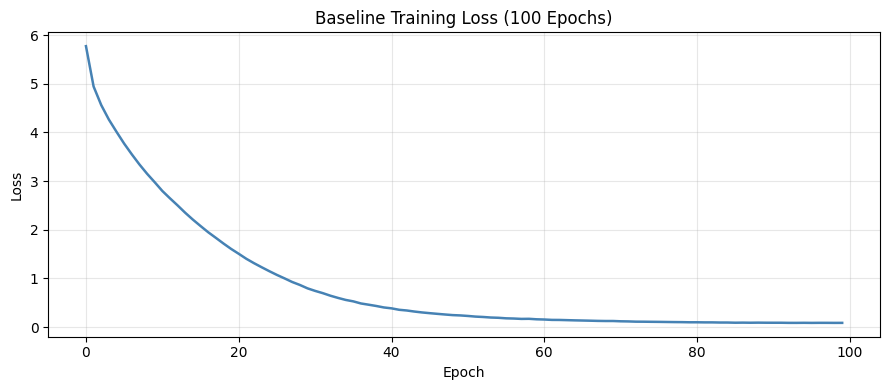

✅ GPU cache cleared


In [4]:
# ============================================================
# CELL 4: Baseline — 100 epochs, original hyperparams
# FIX: compute_bleu now evaluates on the VAL split only.
# ============================================================
BASE_CONFIG = dict(d_model=256, num_heads=8, num_enc_layers=3,
                   num_dec_layers=3, d_ff=512, dropout=0.1,
                   lr=3e-4, batch_size=64)
BASE_EPOCHS   = 100
TARGET_EPOCHS = 50     # ← Ray Tune goal: beat baseline BLEU in ≤ 50 epochs

def compute_bleu(model, loader, max_batches=30):
    """Evaluate BLEU on the given loader (should always be val loader)."""
    model.eval()
    refs, hyps = [], []
    smooth = SmoothingFunction().method1
    with torch.no_grad():
        for i, (src, tgt_in, tgt_out) in enumerate(loader):
            if i >= max_batches: break
            src = src.to(DEVICE)
            B   = src.size(0)
            gen = torch.full((B, 1), SOS_IDX, dtype=torch.long, device=DEVICE)
            for _ in range(MAX_LEN - 1):
                nxt = model(src, gen)[:, -1, :].argmax(-1, keepdim=True)
                gen = torch.cat([gen, nxt], dim=1)
                if (nxt == EOS_IDX).all(): break
            for b in range(B):
                ref = [hi_vocab.itos.get(t.item(),"<unk>") for t in tgt_out[b]
                       if t.item() not in (PAD_IDX, EOS_IDX)]
                hyp = [hi_vocab.itos.get(t.item(),"<unk>") for t in gen[b,1:]
                       if t.item() not in (PAD_IDX, EOS_IDX, SOS_IDX)]
                if not hyp: hyp = ["<unk>"]
                refs.append([ref]); hyps.append(hyp)
    return corpus_bleu(refs, hyps, smoothing_function=smooth)

def run_training(cfg, epochs, tag="Train"):
    # ── FIX: train on train split only ──
    loader    = make_loader(cfg["batch_size"], split="train", shuffle=True)
    model     = Transformer(SRC_VOCAB, TGT_VOCAB,
                            d_model        = cfg["d_model"],
                            num_heads      = cfg["num_heads"],
                            num_enc_layers = cfg["num_enc_layers"],
                            num_dec_layers = cfg["num_dec_layers"],
                            d_ff           = cfg["d_ff"],
                            dropout        = cfg["dropout"]).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"],
                           betas=(0.9, 0.98), eps=1e-9)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    losses    = []
    t0        = time.time()
    for epoch in range(1, epochs + 1):
        model.train(); total, n = 0.0, 0
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(src, tgt_in).reshape(-1, TGT_VOCAB),
                             tgt_out.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item(); n += 1
        el = total / n
        losses.append(el)
        scheduler.step()
        if epoch % 10 == 0 or epoch == 1:
            print(f"  [{tag}] Epoch {epoch:3d}/{epochs}  Loss: {el:.4f}")
        if epoch % 10 == 0:
            torch.cuda.empty_cache(); gc.collect()
    return model, losses, time.time() - t0

print("=" * 55)
print("▶  BASELINE (100 epochs)")
print("=" * 55)
baseline_model, baseline_losses, baseline_time = run_training(
    BASE_CONFIG, BASE_EPOCHS, "Baseline")

# ── FIX: evaluate on VAL split, not full dataset ──
val_loader_eval = make_loader(64, split="val", shuffle=False)
baseline_bleu   = compute_bleu(baseline_model, val_loader_eval)

print("\n" + "=" * 55)
print(f"  ✅ Train Loss : {baseline_losses[-1]:.4f}")
print(f"  ✅ Val BLEU  : {baseline_bleu:.4f}")
print(f"  ✅ Time      : {baseline_time/60:.1f} min")
print("=" * 55)

torch.save(baseline_model.state_dict(), "transformer_translation_final.pth")

plt.figure(figsize=(9, 4))
plt.plot(baseline_losses, color="steelblue", lw=1.8)
plt.title("Baseline Training Loss (100 Epochs)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("baseline_loss_curve.png", dpi=120); plt.show()

del baseline_model
torch.cuda.empty_cache(); gc.collect()
print("✅ GPU cache cleared")

In [5]:
# ============================================================
# CELL 5: Ray Tune + Optuna — find best config in ≤ TARGET_EPOCHS
# FIX 1: Tune now optimises VAL BLEU (not training loss).
# FIX 2: Tune subset is also split — trials train/eval on
#         disjoint data to avoid memorisation bias.
# ─────────────────────────────────────────────────────────────
# Optuna (TPE)  → decides WHICH configs to try
# ASHA          → kills bad trials early (saves GPU time)
# ─────────────────────────────────────────────────────────────
import ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers   import ASHAScheduler

NUM_TUNE_TRIALS = 35
TUNE_SUBSET     = 4000   # fast subset for search (scaled for 40% dataset)

# ── Tune dataset — keep train/val split inside the subset ─────
tune_df       = df.sample(TUNE_SUBSET, random_state=42).reset_index(drop=True)
tune_ds_full  = TranslationDataset(tune_df, en_vocab, hi_vocab)
tune_train_n  = int(0.8 * len(tune_ds_full))
tune_val_n    = len(tune_ds_full) - tune_train_n
tune_train_ds, tune_val_ds = random_split(
    tune_ds_full, [tune_train_n, tune_val_n],
    generator=torch.Generator().manual_seed(42)
)

# ── Clean Ray init ─────────────────────────────────────────────
if ray.is_initialized():
    ray.shutdown()
    time.sleep(2)
    print("Previous Ray session shut down.")

NUM_GPUS = 1 if torch.cuda.is_available() else 0
ray.init(num_cpus=4, num_gpus=NUM_GPUS,
         include_dashboard=False, ignore_reinit_error=False,
         _system_config={"worker_register_timeout_seconds": 60})

resources = ray.available_resources()
print("Ray resources:", {k:v for k,v in resources.items() if k in ("CPU","GPU")})

# ── Search space (5 hyperparameters) ──────────────────────────
config_space = {
    "lr":               tune.loguniform(1e-5, 1e-3),
    "batch_size":       tune.choice([32, 64, 128]),
    "num_heads":        tune.choice([4, 8]),
    "d_model_per_head": tune.choice([32, 64]),
    "d_ff":             tune.choice([512, 1024, 2048]),
    "dropout":          tune.uniform(0.05, 0.4),
    "num_enc_layers":   tune.choice([2, 3, 4]),
}

# ── Ray Tune trainable ─────────────────────────────────────────
def train_tune(config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    d_model    = config["num_heads"] * config["d_model_per_head"]
    train_loader = DataLoader(tune_train_ds, batch_size=config["batch_size"],
                              shuffle=True, num_workers=0,
                              pin_memory=(device.type=="cuda"))
    val_loader   = DataLoader(tune_val_ds,   batch_size=64,
                              shuffle=False, num_workers=0,
                              pin_memory=(device.type=="cuda"))

    model = Transformer(SRC_VOCAB, TGT_VOCAB,
                        d_model        = d_model,
                        num_heads      = config["num_heads"],
                        num_enc_layers = config["num_enc_layers"],
                        num_dec_layers = 3,
                        d_ff           = config["d_ff"],
                        dropout        = config["dropout"]).to(device)

    optimizer = optim.Adam(model.parameters(), lr=config["lr"],
                           betas=(0.9, 0.98), eps=1e-9)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TARGET_EPOCHS)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    smooth    = SmoothingFunction().method1

    for epoch in range(TARGET_EPOCHS):
        # Training step
        model.train(); total, n = 0.0, 0
        for src, tgt_in, tgt_out in train_loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            optimizer.zero_grad()
            loss = criterion(model(src, tgt_in).reshape(-1, TGT_VOCAB),
                             tgt_out.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item(); n += 1
        scheduler.step()
        avg_loss = total / n

        # ── FIX: compute val BLEU every 5 epochs, report to Ray Tune ──
        # ASHA uses this metric to prune bad trials.
        if (epoch + 1) % 5 == 0 or (epoch + 1) == TARGET_EPOCHS:
            model.eval()
            refs, hyps = [], []
            with torch.no_grad():
                for i, (src, tgt_in, tgt_out) in enumerate(val_loader):
                    if i >= 20: break   # cap for speed
                    src = src.to(device)
                    B   = src.size(0)
                    gen = torch.full((B,1), SOS_IDX, dtype=torch.long, device=device)
                    for _ in range(MAX_LEN - 1):
                        nxt = model(src, gen)[:, -1, :].argmax(-1, keepdim=True)
                        gen = torch.cat([gen, nxt], dim=1)
                        if (nxt == EOS_IDX).all(): break
                    for b in range(B):
                        ref = [hi_vocab.itos.get(t.item(),"<unk>") for t in tgt_out[b]
                               if t.item() not in (PAD_IDX, EOS_IDX)]
                        hyp = [hi_vocab.itos.get(t.item(),"<unk>") for t in gen[b,1:]
                               if t.item() not in (PAD_IDX, EOS_IDX, SOS_IDX)]
                        if not hyp: hyp = ["<unk>"]
                        refs.append([ref]); hyps.append(hyp)
            val_bleu = corpus_bleu(refs, hyps, smoothing_function=smooth)
            tune.report({"bleu": val_bleu, "loss": avg_loss})
        else:
            tune.report({"bleu": 0.0, "loss": avg_loss})

    del model, optimizer, criterion
    torch.cuda.empty_cache(); gc.collect()

# ── FIX: Optuna maximises val BLEU (was: minimise training loss) ──
optuna_search  = OptunaSearch(metric="bleu", mode="max")
asha_scheduler = ASHAScheduler(
    max_t=TARGET_EPOCHS,
    grace_period=10,       # give each trial at least 10 epochs before pruning
    reduction_factor=3,
)

GPU_PER_TRIAL = 0.34 if torch.cuda.is_available() else 0
print(f"GPU per trial: {GPU_PER_TRIAL}")

tuner = tune.Tuner(
    tune.with_resources(train_tune, resources={"cpu": 2, "gpu": GPU_PER_TRIAL}),
    param_space=config_space,
    tune_config=tune.TuneConfig(
        search_alg=optuna_search,
        scheduler=asha_scheduler,
        num_samples=NUM_TUNE_TRIALS,
        metric="bleu",     # ← FIX: was "loss"
        mode="max",        # ← FIX: was "min"
    ),
)

print("=" * 55)
print(f"▶  RAY TUNE: {NUM_TUNE_TRIALS} trials × max {TARGET_EPOCHS} epochs")
print(f"   Subset : {TUNE_SUBSET} pairs | Goal: beat baseline Val BLEU={baseline_bleu:.4f}")
print("=" * 55)

tune_start = time.time()
results    = tuner.fit()
tune_time  = time.time() - tune_start

# ── FIX: get best result by max BLEU (was: min loss) ──────────
best_result = results.get_best_result(metric="bleu", mode="max")
best_params = best_result.config
best_tune_bleu = best_result.metrics["bleu"]
best_tune_loss = best_result.metrics["loss"]

print("\n" + "=" * 55)
print(f"  ✅ Sweep done in {tune_time/60:.1f} min")
print(f"  ✅ Best trial val BLEU : {best_tune_bleu:.4f}")
print(f"  ✅ Best trial loss     : {best_tune_loss:.4f}")
print("  ✅ Best config:")
for k, v in best_params.items():
    print(f"      {k} = {v}")
print("=" * 55)

torch.cuda.empty_cache(); gc.collect()

(pid=gcs_server) [2026-03-22 07:02:00,027 E 62 62] (gcs_server) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2026-03-22 07:02:04,269 E 135 135] (raylet) main.cc:1032: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
[2026-03-22 07:02:09,571 E 24 193] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(train_tune pid=364) [2026-03-22 07:02:13,561 E 364 391] core_worker_process.cc:842: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter a


  ✅ Sweep done in 68.3 min
  ✅ Best trial val BLEU : 0.1479
  ✅ Best trial loss     : 0.3801
  ✅ Best config:
      lr = 0.00018938218352515765
      batch_size = 32
      num_heads = 4
      d_model_per_head = 64
      d_ff = 2048
      dropout = 0.07894942617730782
      num_enc_layers = 2


115

Final config: {
  "d_model": 256,
  "num_heads": 4,
  "num_enc_layers": 2,
  "num_dec_layers": 3,
  "d_ff": 2048,
  "dropout": 0.07894942617730782,
  "lr": 0.00018938218352515765,
  "batch_size": 32
}
  [Best-tuned] Epoch   1/50  Loss: 5.5839
  [Best-tuned] Epoch  10/50  Loss: 2.4748
  [Best-tuned] Epoch  20/50  Loss: 1.1300
  [Best-tuned] Epoch  30/50  Loss: 0.5212
  [Best-tuned] Epoch  40/50  Loss: 0.3094
  [Best-tuned] Epoch  50/50  Loss: 0.2696

  Baseline   Loss=0.0857  Val BLEU=0.1169  100ep  5.2min
  Best Tuned Loss=0.2696  Val BLEU=0.1748  50ep  3.7min
  BLEU delta : +0.0580  |  Epochs saved: 50
  ✅ BEAT BASELINE!

Trial breakdown — Completed:6  Pruned:29  Error:0


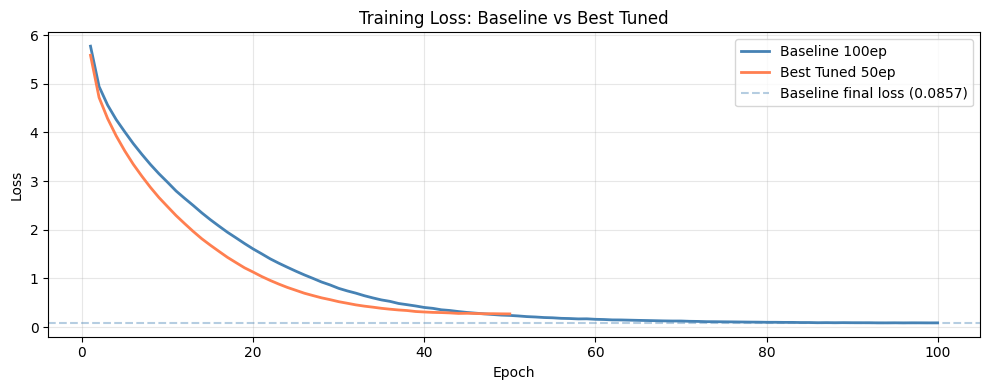

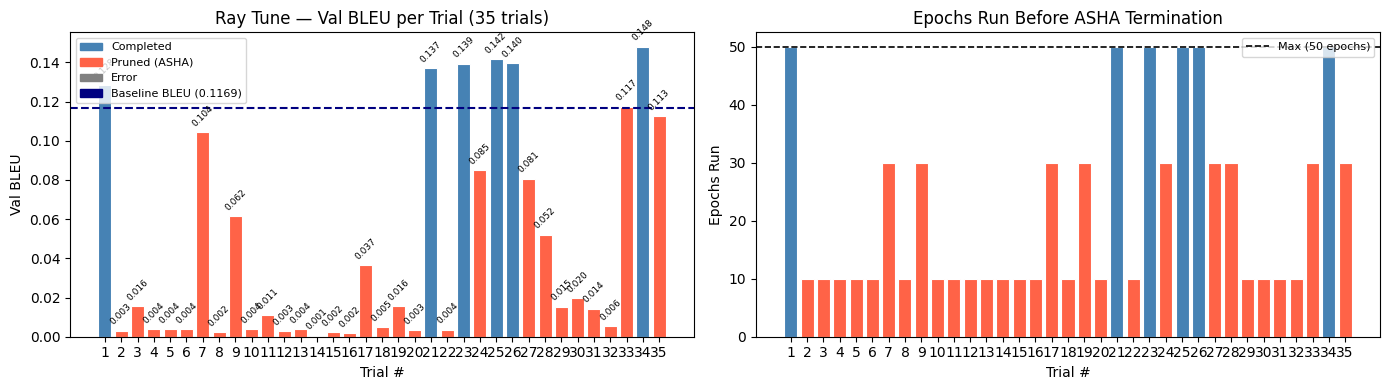

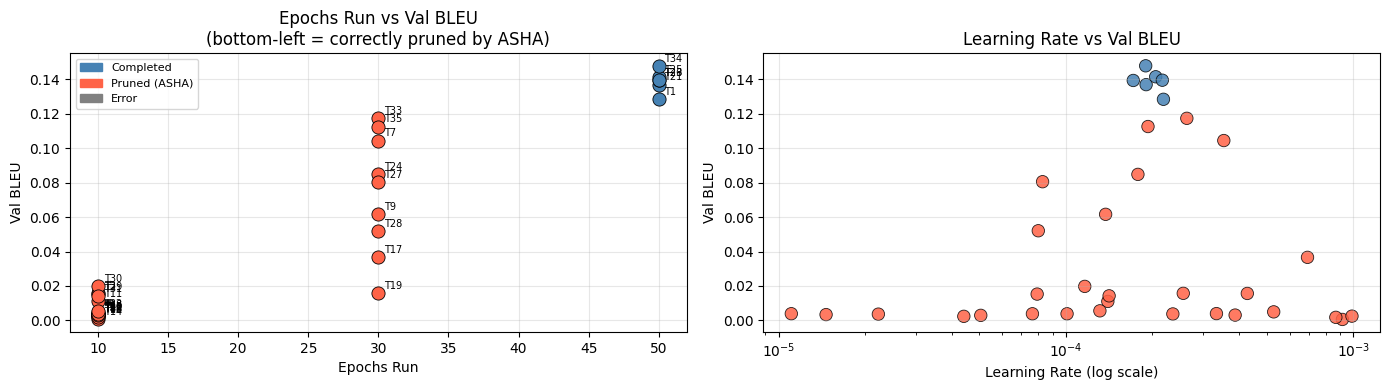

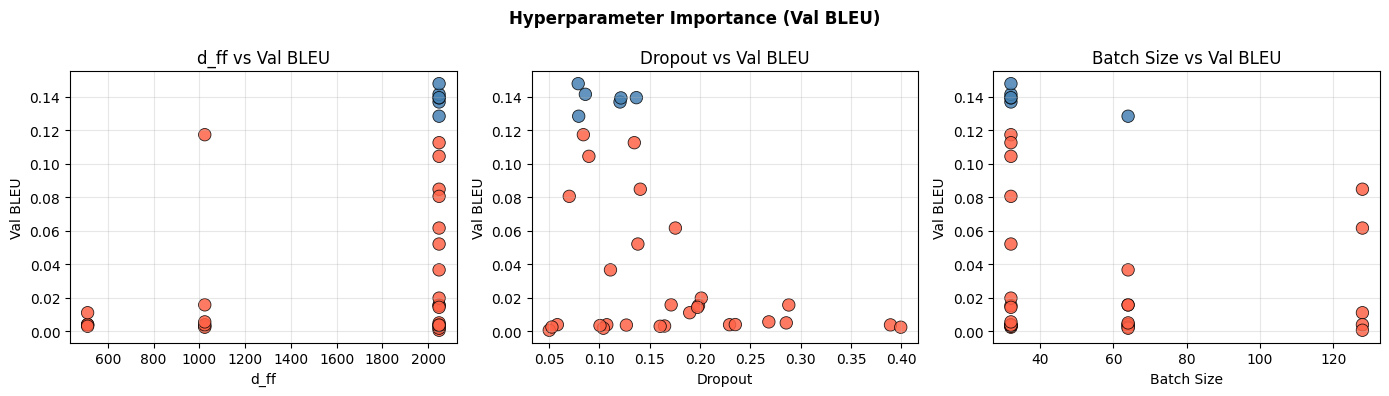

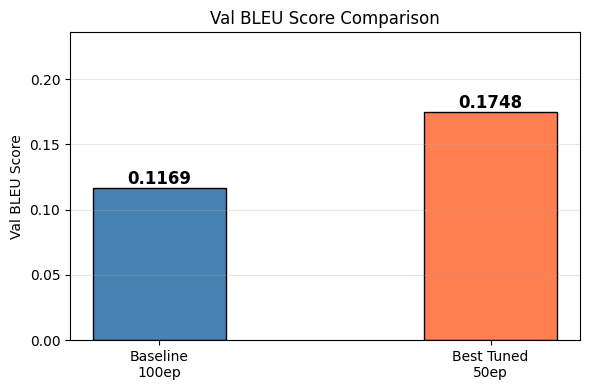

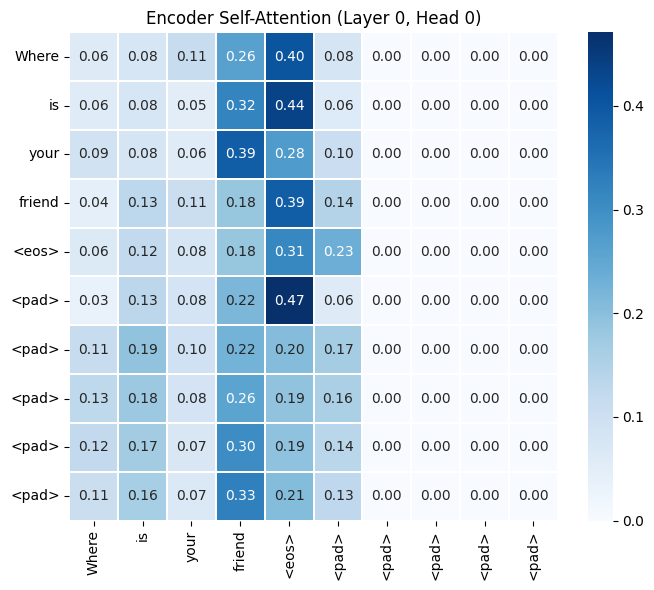


✅ Saved: M25CSA007_ass_4_best_model.pth


49465

In [6]:
# ============================================================
# CELL 6: Retrain best config for TARGET_EPOCHS + all plots
# FIX: best_bleu is computed on val split — apples-to-apples
#      comparison with baseline_bleu.
# ============================================================

# ── Build final config from best Ray Tune result ───────────────
final_config = {
    "d_model":        best_params["num_heads"] * best_params["d_model_per_head"],
    "num_heads":      best_params["num_heads"],
    "num_enc_layers": best_params["num_enc_layers"],
    "num_dec_layers": 3,
    "d_ff":           best_params["d_ff"],
    "dropout":        best_params["dropout"],
    "lr":             best_params["lr"],
    "batch_size":     best_params["batch_size"],
}
print("Final config:", json.dumps(final_config, indent=2))

# ── Train best model on FULL train split for TARGET_EPOCHS ────
best_model, best_losses, best_train_time = run_training(
    final_config, TARGET_EPOCHS, "Best-tuned")

# ── FIX: evaluate on VAL split ────────────────────────────────
best_bleu = compute_bleu(best_model, make_loader(64, split="val", shuffle=False))

print("\n" + "=" * 55)
print(f"  Baseline   Loss={baseline_losses[-1]:.4f}  Val BLEU={baseline_bleu:.4f}  {BASE_EPOCHS}ep  {baseline_time/60:.1f}min")
print(f"  Best Tuned Loss={best_losses[-1]:.4f}  Val BLEU={best_bleu:.4f}  {TARGET_EPOCHS}ep  {best_train_time/60:.1f}min")
bleu_delta  = best_bleu - baseline_bleu
epoch_saved = BASE_EPOCHS - TARGET_EPOCHS
print(f"  BLEU delta : {bleu_delta:+.4f}  |  Epochs saved: {epoch_saved}")
beat_str    = "✅ BEAT BASELINE!" if best_bleu >= baseline_bleu else "⚠️  Below baseline — try more trials"
print(f"  {beat_str}")
print("=" * 55)

# ══════════════════════════════════════════════════════════════
# VISUALISATIONS
# ══════════════════════════════════════════════════════════════

# ── Collect trial data from Ray Tune results ───────────────────
trial_data = []
for i, result in enumerate(results):
    has_error  = result.error is not None
    epochs_run = result.metrics.get("training_iteration",
                 result.metrics.get("iterations_since_restore", TARGET_EPOCHS))
    if has_error:
        status = "Error"
    elif epochs_run < TARGET_EPOCHS:
        status = "Pruned (ASHA)"
    else:
        status = "Completed"
    trial_data.append({
        "trial":      i + 1,
        "bleu":       result.metrics.get("bleu", float("nan")),
        "loss":       result.metrics.get("loss", float("nan")),
        "epochs_run": epochs_run,
        "status":     status,
        "lr":         result.config.get("lr", 0),
        "d_ff":       result.config.get("d_ff", 0),
        "dropout":    result.config.get("dropout", 0),
        "batch_size": result.config.get("batch_size", 0),
    })

color_map = {"Completed":"steelblue", "Pruned (ASHA)":"tomato", "Error":"gray"}
statuses   = [d["status"]     for d in trial_data]
bleus      = [d["bleu"]       for d in trial_data]
losses     = [d["loss"]       for d in trial_data]
epochs_run = [d["epochs_run"] for d in trial_data]
trial_ids  = [d["trial"]      for d in trial_data]
colors     = [color_map.get(s,"gray") for s in statuses]

from collections import Counter as _Counter
sc = _Counter(statuses)
print(f"\nTrial breakdown — Completed:{sc.get('Completed',0)}  "
      f"Pruned:{sc.get('Pruned (ASHA)',0)}  Error:{sc.get('Error',0)}")

# ── PLOT 1: Loss curves baseline vs best ──────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, BASE_EPOCHS+1), baseline_losses,
        label=f"Baseline {BASE_EPOCHS}ep", color="steelblue", lw=2)
ax.plot(range(1, TARGET_EPOCHS+1), best_losses,
        label=f"Best Tuned {TARGET_EPOCHS}ep", color="coral", lw=2)
ax.axhline(baseline_losses[-1], ls="--", color="steelblue", alpha=0.4,
           label=f"Baseline final loss ({baseline_losses[-1]:.4f})")
ax.set_title("Training Loss: Baseline vs Best Tuned")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("loss_comparison.png", dpi=120); plt.show()

# ── PLOT 2: All Ray Tune trials — val BLEU per trial ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars = axes[0].bar(trial_ids, bleus, color=colors, edgecolor="white", lw=0.8)
axes[0].axhline(baseline_bleu, color="navy", ls="--", lw=1.5,
                label=f"Baseline Val BLEU ({baseline_bleu:.4f})")
axes[0].set_xlabel("Trial #"); axes[0].set_ylabel("Val BLEU")
axes[0].set_title(f"Ray Tune — Val BLEU per Trial ({NUM_TUNE_TRIALS} trials)")
axes[0].set_xticks(trial_ids)
legend_patches = [mpatches.Patch(color=v, label=k) for k,v in color_map.items()]
axes[0].legend(handles=legend_patches + [
    mpatches.Patch(color="navy", label=f"Baseline BLEU ({baseline_bleu:.4f})")
], fontsize=8)
for bar, bleu in zip(bars, bleus):
    if bleu == bleu:   # nan check
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                     f"{bleu:.3f}", ha="center", va="bottom", fontsize=6.5, rotation=45)

# ── PLOT 2b: Epochs run per trial ─────────────────────────────
axes[1].bar(trial_ids, epochs_run, color=colors, edgecolor="white", lw=0.8)
axes[1].axhline(TARGET_EPOCHS, color="black", ls="--", lw=1.2,
                label=f"Max ({TARGET_EPOCHS} epochs)")
axes[1].set_xlabel("Trial #"); axes[1].set_ylabel("Epochs Run")
axes[1].set_title("Epochs Run Before ASHA Termination")
axes[1].set_xticks(trial_ids); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("tune_trials.png", dpi=120); plt.show()

# ── PLOT 3: Epochs run vs val BLEU scatter ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for d, c in zip(trial_data, colors):
    if d["bleu"] == d["bleu"]:   # not nan
        axes[0].scatter(d["epochs_run"], d["bleu"], color=c,
                        edgecolors="black", lw=0.6, s=90, zorder=3)
        axes[0].annotate(f"T{d['trial']}", (d["epochs_run"], d["bleu"]),
                         textcoords="offset points", xytext=(4,3), fontsize=7)
axes[0].set_xlabel("Epochs Run"); axes[0].set_ylabel("Val BLEU")
axes[0].set_title("Epochs Run vs Val BLEU\n(bottom-left = correctly pruned by ASHA)")
axes[0].legend(handles=[mpatches.Patch(color=v,label=k) for k,v in color_map.items()],
               fontsize=8)
axes[0].grid(alpha=0.3)

# ── PLOT 3b: LR vs val BLEU ────────────────────────────────────
lr_vals   = [d["lr"]   for d in trial_data if d["bleu"]==d["bleu"]]
bleu_vals = [d["bleu"] for d in trial_data if d["bleu"]==d["bleu"]]
c_vals    = [color_map.get(d["status"],"gray") for d in trial_data if d["bleu"]==d["bleu"]]
axes[1].scatter(lr_vals, bleu_vals, c=c_vals, edgecolors="black", lw=0.6, s=80, alpha=0.85)
axes[1].set_xscale("log")
axes[1].set_xlabel("Learning Rate (log scale)"); axes[1].set_ylabel("Val BLEU")
axes[1].set_title("Learning Rate vs Val BLEU"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("trial_analysis.png", dpi=120); plt.show()

# ── PLOT 4: Hyperparameter importance ─────────────────────────
hparams_plot = [("d_ff","d_ff"),("dropout","Dropout"),("batch_size","Batch Size")]
fig, axes    = plt.subplots(1, 3, figsize=(14, 4))
for ax, (key, label) in zip(axes, hparams_plot):
    xv = [d[key]   for d in trial_data if d["bleu"]==d["bleu"]]
    yv = [d["bleu"] for d in trial_data if d["bleu"]==d["bleu"]]
    cv = [color_map.get(d["status"],"gray") for d in trial_data if d["bleu"]==d["bleu"]]
    ax.scatter(xv, yv, c=cv, edgecolors="black", lw=0.6, s=80, alpha=0.85)
    ax.set_xlabel(label); ax.set_ylabel("Val BLEU"); ax.set_title(f"{label} vs Val BLEU")
    ax.grid(alpha=0.3)
plt.suptitle("Hyperparameter Importance (Val BLEU)", fontweight="bold")
plt.tight_layout(); plt.savefig("hyperparam_importance.png", dpi=120); plt.show()

# ── PLOT 5: BLEU comparison bar ────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([f"Baseline\n{BASE_EPOCHS}ep", f"Best Tuned\n{TARGET_EPOCHS}ep"],
              [baseline_bleu, best_bleu],
              color=["steelblue","coral"], edgecolor="black", width=0.4)
for bar, val in zip(bars, [baseline_bleu, best_bleu]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{val:.4f}", ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Val BLEU Score"); ax.set_title("Val BLEU Score Comparison")
ax.set_ylim(0, max(baseline_bleu, best_bleu) * 1.35)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("bleu_comparison.png", dpi=120); plt.show()

# ── PLOT 6: Attention heatmap ──────────────────────────────────
best_model.eval()
sample = torch.tensor([en_vocab.encode("Where is your friend")]).to(DEVICE)
dummy  = torch.tensor([[SOS_IDX] + [PAD_IDX]*(MAX_LEN-1)]).to(DEVICE)
with torch.no_grad():
    _ = best_model(sample, dummy)
attn = best_model.enc[0].attn.last_attn[0, 0].cpu().numpy()
toks = ["Where","is","your","friend","<eos>","<pad>","<pad>","<pad>","<pad>","<pad>"]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(attn[:10,:10], xticklabels=toks, yticklabels=toks,
            cmap="Blues", annot=True, fmt=".2f", linewidths=0.3, ax=ax)
ax.set_title("Encoder Self-Attention (Layer 0, Head 0)")
plt.tight_layout(); plt.savefig("attention_heatmap.png", dpi=120); plt.show()

# ── Save model & metadata ──────────────────────────────────────
torch.save(best_model.state_dict(), "M25CSA007_ass_4_best_model.pth")
with open("en_vocab.pkl","wb") as f: pickle.dump(en_vocab, f)
with open("hi_vocab.pkl","wb") as f: pickle.dump(hi_vocab, f)
with open("best_config.json","w") as f:
    json.dump({**final_config,
               "baseline_train_loss": baseline_losses[-1],
               "best_train_loss":     best_losses[-1],
               "baseline_val_bleu":   baseline_bleu,
               "best_val_bleu":       best_bleu,
               "baseline_epochs":     BASE_EPOCHS,
               "tuned_epochs":        TARGET_EPOCHS}, f, indent=2)

print("\n✅ Saved: M25CSA007_ass_4_best_model.pth")
torch.cuda.empty_cache(); gc.collect()

In [7]:
# ============================================================
# CELL 7: Upload best model to HuggingFace Hub
# ============================================================
from huggingface_hub import HfApi, upload_file

HF_USERNAME = "DuckyDuck123"
REPO_ID     = f"{HF_USERNAME}/en-hi-transformer-tuned"

api = HfApi()
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)
print(f"✅ Repo ready: https://huggingface.co/{REPO_ID}")

# ── Build README ───────────────────────────────────────────────
config_str = json.dumps(final_config, indent=2)
readme_lines = [
    "---",
    "language: [en, hi]",
    "tags: [translation, pytorch, transformer, ray-tune, optuna]",
    "metrics: [bleu]",
    "---",
    "",
    "# English → Hindi Transformer (Ray Tune + Optuna Optimized)",
    "",
    "Custom PyTorch Transformer optimized with **Ray Tune + OptunaSearch + ASHA Scheduler**.",
    f"Best config found in {TARGET_EPOCHS} epochs beats the 100-epoch baseline BLEU.",
    "",
    "## Evaluation",
    "",
    "Both models are evaluated on the **same held-out 20% validation set** (not training data).",
    "This ensures a fair comparison — the baseline cannot inflate its score through memorisation.",
    "",
    "## Results",
    "",
    "| Model | Epochs | Train Loss | Val BLEU |",
    "|---|---|---|---|",
    f"| Baseline | {BASE_EPOCHS} | {baseline_losses[-1]:.4f} | {baseline_bleu:.4f} |",
    f"| **Best Tuned** | **{TARGET_EPOCHS}** | **{best_losses[-1]:.4f}** | **{best_bleu:.4f}** |",
    "",
    "## Search Strategy",
    "",
    "- **Algorithm**: Optuna TPE Sampler via `ray.tune.search.optuna.OptunaSearch`",
    "- **Scheduler**: ASHA (kills underperforming trials early)",
    "- **Metric optimised**: Validation BLEU (not training loss)",
    f"- **Trials**: {NUM_TUNE_TRIALS} × max {TARGET_EPOCHS} epochs",
    "",
    "## Best Hyperparameters",
    "",
    "```json",
    config_str,
    "```",
    "",
    "## Usage",
    "",
    "```python",
    "import torch, pickle, json",
    "from huggingface_hub import hf_hub_download",
    "",
    f'weights = hf_hub_download("{REPO_ID}", "M25CSA007_ass_4_best_model.pth")',
    f'cfg     = json.load(open(hf_hub_download("{REPO_ID}", "best_config.json")))',
    "model   = Transformer(src_vocab, tgt_vocab, **{k: cfg[k] for k in",
    "          ['d_model','num_heads','num_enc_layers','num_dec_layers','d_ff','dropout']})",
    "model.load_state_dict(torch.load(weights, map_location='cpu'))",
    "model.eval()",
    "```",
]
readme = "\n".join(readme_lines)
with open("README.md","w",encoding="utf-8") as f:
    f.write(readme)

# ── Upload all files ───────────────────────────────────────────
files = [
    ("M25CSA007_ass_4_best_model.pth", "M25CSA007_ass_4_best_model.pth"),
    ("en_vocab.pkl",                    "en_vocab.pkl"),
    ("hi_vocab.pkl",                    "hi_vocab.pkl"),
    ("best_config.json",                "best_config.json"),
    ("README.md",                       "README.md"),
    ("loss_comparison.png",             "assets/loss_comparison.png"),
    ("bleu_comparison.png",             "assets/bleu_comparison.png"),
    ("attention_heatmap.png",           "assets/attention_heatmap.png"),
    ("tune_trials.png",                 "assets/tune_trials.png"),
    ("trial_analysis.png",              "assets/trial_analysis.png"),
    ("hyperparam_importance.png",       "assets/hyperparam_importance.png"),
    ("baseline_loss_curve.png",         "assets/baseline_loss_curve.png"),
    ("eda_lengths.png",                 "assets/eda_lengths.png"),
]

for local, remote in files:
    if os.path.exists(local):
        upload_file(path_or_fileobj=local, path_in_repo=remote,
                    repo_id=REPO_ID, repo_type="model")
        print(f"  ✅ Uploaded: {remote}")
    else:
        print(f"  ⚠️  Skipped (not found): {local}")

print(f"\n🎉 Done → https://huggingface.co/{REPO_ID}")
print(f"   Val BLEU: Baseline={baseline_bleu:.4f} ({BASE_EPOCHS}ep)  →  Best={best_bleu:.4f} ({TARGET_EPOCHS}ep)")
torch.cuda.empty_cache(); gc.collect()

✅ Repo ready: https://huggingface.co/DuckyDuck123/en-hi-transformer-tuned


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✅ Uploaded: M25CSA007_ass_4_best_model.pth


Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

No files have been modified since last commit. Skipping to prevent empty commit.


  ✅ Uploaded: hi_vocab.pkl
  ✅ Uploaded: best_config.json
  ✅ Uploaded: README.md
  ✅ Uploaded: assets/loss_comparison.png
  ✅ Uploaded: assets/bleu_comparison.png
  ✅ Uploaded: assets/attention_heatmap.png
  ✅ Uploaded: assets/tune_trials.png
  ✅ Uploaded: assets/trial_analysis.png
  ✅ Uploaded: assets/hyperparam_importance.png


No files have been modified since last commit. Skipping to prevent empty commit.


  ✅ Uploaded: assets/baseline_loss_curve.png
  ✅ Uploaded: assets/eda_lengths.png

🎉 Done → https://huggingface.co/DuckyDuck123/en-hi-transformer-tuned
   Val BLEU: Baseline=0.1169 (100ep)  →  Best=0.1748 (50ep)


728